# Spark Modeling
this is the bread and butter of the big data project. Here we shall take the ML pipeline that we built in the 02_modeling.ipynb notebook and rebuild it in pyspark Ml

In [2]:
# ===============================================
# BASIC SETUP: GIT Auth and mounting google drive
# ================================================

from google.colab import drive, userdata
import sys

# Standard mount to access the config file initially
drive.mount('/content/drive')
PROJECT_ROOT = userdata.get('BIG_DATA_PATH')
sys.path.append(PROJECT_ROOT + "/src/")

from utils.config import initialize_project
initialize_project()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Authenticated as: Spencer Novaco
Working Directory: /content/drive/MyDrive/Sprint 2026/CIS 5570/Big-data-group-1/Room-Occupancy-Detection


In [3]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.types import (
    StructType, StructField, IntegerType, StringType, DoubleType
)
from pyspark.sql.functions import col

In [4]:
spark = SparkSession.builder.appName("RoomOccupancySparkML").getOrCreate()

schema = StructType([
    StructField("row_id", IntegerType(), True),
    StructField("date", StringType(), True),
    StructField("Temperature", DoubleType(), True),
    StructField("Humidity", DoubleType(), True),
    StructField("Light", DoubleType(), True),
    StructField("CO2", DoubleType(), True),
    StructField("HumidityRatio", DoubleType(), True),
    StructField("Occupancy", IntegerType(), True)
])

train_sdf = spark.read.csv("data/raw/datatraining.txt", header=False, schema=schema, sep=",")
test1_sdf = spark.read.csv("data/raw/datatest.txt", header=False, schema=schema, sep=",")
test2_sdf = spark.read.csv("data/raw/datatest2.txt", header=False, schema=schema, sep=",")


In [5]:
train_sdf.printSchema()
train_sdf.show(5)

root
 |-- row_id: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Humidity: double (nullable = true)
 |-- Light: double (nullable = true)
 |-- CO2: double (nullable = true)
 |-- HumidityRatio: double (nullable = true)
 |-- Occupancy: integer (nullable = true)

+------+-------------------+-----------+--------+-----+------+-------------------+---------+
|row_id|               date|Temperature|Humidity|Light|   CO2|      HumidityRatio|Occupancy|
+------+-------------------+-----------+--------+-----+------+-------------------+---------+
|  NULL|        Temperature|       NULL|    NULL| NULL|  NULL|               NULL|     NULL|
|     1|2015-02-04 17:51:00|      23.18|  27.272|426.0|721.25|0.00479298817650529|        1|
|     2|2015-02-04 17:51:59|      23.15| 27.2675|429.5| 714.0|0.00478344094931065|        1|
|     3|2015-02-04 17:53:00|      23.15|  27.245|426.0| 713.5|0.00477946352442199|        1|
|     4|2015-02-04 17:54:0

In [6]:
train_sdf = train_sdf.filter(col("row_id").isNotNull()).drop("row_id")
test1_sdf = test1_sdf.filter(col("row_id").isNotNull()).drop("row_id")
test2_sdf = test2_sdf.filter(col("row_id").isNotNull()).drop("row_id")

In [7]:
train_sdf.printSchema()
train_sdf.show(5)

root
 |-- date: string (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Humidity: double (nullable = true)
 |-- Light: double (nullable = true)
 |-- CO2: double (nullable = true)
 |-- HumidityRatio: double (nullable = true)
 |-- Occupancy: integer (nullable = true)

+-------------------+-----------+--------+-----+------+-------------------+---------+
|               date|Temperature|Humidity|Light|   CO2|      HumidityRatio|Occupancy|
+-------------------+-----------+--------+-----+------+-------------------+---------+
|2015-02-04 17:51:00|      23.18|  27.272|426.0|721.25|0.00479298817650529|        1|
|2015-02-04 17:51:59|      23.15| 27.2675|429.5| 714.0|0.00478344094931065|        1|
|2015-02-04 17:53:00|      23.15|  27.245|426.0| 713.5|0.00477946352442199|        1|
|2015-02-04 17:54:00|      23.15|    27.2|426.0|708.25|0.00477150882608175|        1|
|2015-02-04 17:55:00|       23.1|    27.2|426.0| 704.5|0.00475699293331518|        1|
+-------------------+-------

In [8]:
print("Train rows:", train_sdf.count())
print("Test1 rows:", test1_sdf.count())
print("Test2 rows:", test2_sdf.count())

Train rows: 8143
Test1 rows: 2665
Test2 rows: 9752


In [9]:
features = ["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]
label_col = "Occupancy"

In [10]:
# we transform our features into a feature vectors
assembler = VectorAssembler(inputCols=features, outputCol="raw_features")


In [11]:
# Since we are using Logistic Regression model, we have to standazie all features such that
# all the features are on the same scale.
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withMean=True, withStd=True)


In [12]:
# implementation of the logistic regression model
lr = LogisticRegression(featuresCol="features", labelCol=label_col, maxIter=1000, regParam=0.01,elasticNetParam=0.0)

lr_pipeline = Pipeline(stages=[assembler, scaler, lr])
lr_model = lr_pipeline.fit(train_sdf)

lr_pred_test1 = lr_model.transform(test1_sdf)
lr_pred_test2 = lr_model.transform(test2_sdf)

In [13]:
def spark_evaluate(pred_df, label_col="Occupancy", prediction_col="prediction"):
    metrics = {}
    for metric_name in ["accuracy", "f1", "weightedPrecision", "weightedRecall"]:
        evaluator = MulticlassClassificationEvaluator(
            labelCol=label_col,
            predictionCol=prediction_col,
            metricName=metric_name
        )
        metrics[metric_name] = evaluator.evaluate(pred_df)
    return metrics

print("LR Test1:", spark_evaluate(lr_pred_test1))
print("LR Test2:", spark_evaluate(lr_pred_test2))

LR Test1: {'accuracy': 0.9782363977485928, 'f1': 0.9783501694123646, 'weightedPrecision': 0.9792487447522046, 'weightedRecall': 0.9782363977485928}
LR Test2: {'accuracy': 0.9928219852337982, 'f1': 0.9928535611257423, 'weightedPrecision': 0.9929618455874456, 'weightedRecall': 0.9928219852337983}


# We now have to simulate Scale:
  in this section we simulate scale so that we can demonstrate the powers of spark

In [14]:
# We first have to time our original Spark model with the original dataset
import time

start = time.time()
small_model = lr_pipeline.fit(train_sdf)
end = time.time()

small_time = end - start
print("Original training time:", small_time)

Original training time: 3.2411692142486572


In [15]:
# we create a larger dataset by simulating it
big_sdf = train_sdf

for _ in range(200):  #2^200 = almost 200x the original dataset
    big_sdf = big_sdf.union(train_sdf)

In [16]:
#checking for size
print("Rows:", big_sdf.count())

Rows: 1636743


Because the original dataset is relatively small, our scale was simulated by repeated union operations rather than collected from a naturally large sensor stream

In [17]:
# check the num of partitions spark automatically assigns
print("Partitions:", big_sdf.rdd.getNumPartitions())

Partitions: 201


In [ ]:
# we retrain the model using the scaled dataset with the default partitions pyspark uses and then measure the time it takes to do it
import time

start = time.time()
big_model = lr_pipeline.fit(big_sdf)
end = time.time()

print("Training time:", end - start)

Training time: 382.5289533138275


In [ ]:
spark.sparkContext.defaultParallelism

2

# Experiment 1: do number of Spark partitions influence the time it takes to fit the ML model?
We test out different sizes of partitions to investigate the time taken

In [ ]:
# We cache our dataset before we repeatedly fit it using spark so that spark doesnt rebuild it every time
big_sdf = big_sdf.cache()
big_sdf.count()

1636743

In [ ]:
partition_results = []

for p in [2, 4, 8, 16, 32, 64, 151, 201, 260]:
    temp_df = big_sdf.repartition(p)

    start = time.time()
    _ = lr_pipeline.fit(temp_df)
    end = time.time()

    train_time = end - start

    partition_results.append((p, train_time))
    print(f"Partitions: {p}, Training time: {train_time:.2f} sec")

Partitions: 2, Training time: 71.74 sec
Partitions: 4, Training time: 63.70 sec
Partitions: 8, Training time: 64.45 sec
Partitions: 16, Training time: 68.97 sec
Partitions: 32, Training time: 74.87 sec
Partitions: 64, Training time: 92.93 sec
Partitions: 151, Training time: 120.18 sec
Partitions: 201, Training time: 118.14 sec
Partitions: 260, Training time: 135.94 sec


In [ ]:
# we use pandas to plot
import pandas as pd
import matplotlib.pyplot as plt

partition_df = pd.DataFrame(partition_results, columns=["Partitions", "TrainingTimeSec"])
partition_df

,Partitions,TrainingTimeSec
0,2,71.742999
1,4,63.698926
2,8,64.451197
3,16,68.974534
4,32,74.872166
5,64,92.930681
6,151,120.178505
7,201,118.144031
8,260,135.942710


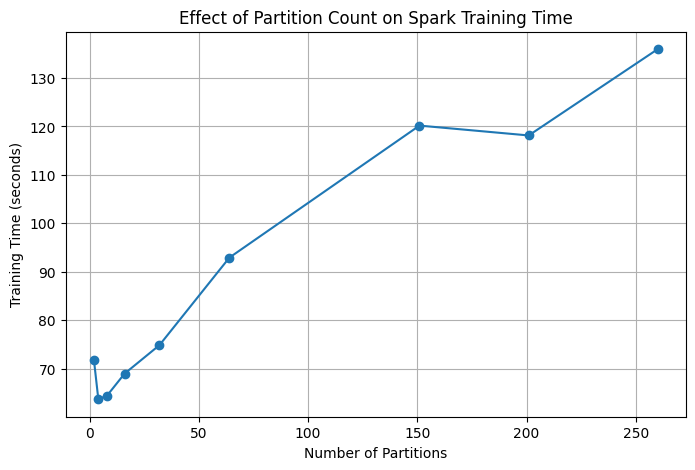

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(partition_df["Partitions"], partition_df["TrainingTimeSec"], marker="o")
plt.xlabel("Number of Partitions")
plt.ylabel("Training Time (seconds)")
plt.title("Effect of Partition Count on Spark Training Time")
plt.grid(True)
plt.show()

## Takeaway
we simulated scale by repeatedly unioning the training dataset until it reached over 1.6 million rows. Training time increased substantially compared to the original dataset, showing the computational impact of scale. We also observed that repeated union operations created 201 partitions, which is far above the runtime’s default parallelism of 2 cores. This demonstrates an important Spark concept: partition count must be tuned carefully, since too many partitions can introduce scheduling overhead rather than improving performance. Overall, the experiment shows that Spark is suitable for scalable sensor-data pipelines, but performance depends not only on data size, but also on how data is partitioned.

In [ ]:
# table to show the training time of the original dataset vs the scaled dataset using the default spark partitions
size_df = pd.DataFrame({
    "Dataset": ["Original", "Scaled"],
    "Rows": [train_sdf.count(), big_sdf.count()],
    "TrainingTimeSec": [small_time, 420.5621]
})

size_df

,Dataset,Rows,TrainingTimeSec
0,Original,8143,3.241169
1,Scaled,1636743,420.562100


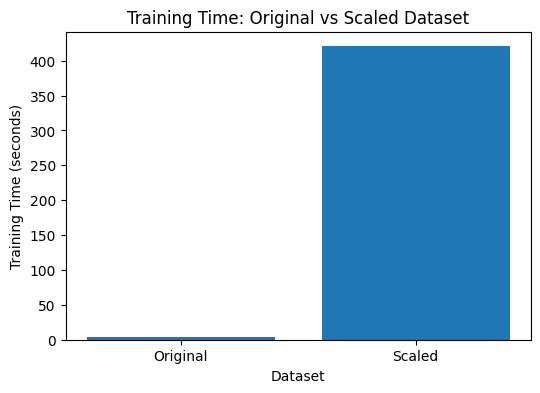

In [ ]:
# Plot showing the same thing as above
plt.figure(figsize=(6,4))
plt.bar(size_df["Dataset"], size_df["TrainingTimeSec"])
plt.xlabel("Dataset")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time: Original vs Scaled Dataset")
plt.show()

# Data Streaming Simulation
In this section we shall simulate real time data streaming and how we can predict room occupancy in real time with the power of spark helping us stream and handle the data in real time